In [5]:
import numpy as np
import torch
import gc
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [6]:
def train_torch_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50):
    model.to(device)
    history = {'train_loss':[], 'val_loss':[]}
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()*xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        # validation loss
        model.eval()
        with torch.no_grad():
            val_running = 0.0
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                val_running += loss.item()*xb.size(0)
            val_loss = val_running / len(val_loader.dataset)
            history['val_loss'].append(val_loss)
    return history

In [7]:
def partB_wine(device=torch.device('cpu')):
    data = load_wine()
    X = data.data
    y = data.target.astype(np.int64)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, random_state=42, stratify=y)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)
    yte_t = torch.tensor(yte, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(Xtr_t,ytr_t), batch_size=32, shuffle=True)
    test_loader = DataLoader(TensorDataset(Xte_t,yte_t), batch_size=64)

    class WineNet(nn.Module):
        def __init__(self, in_dim, n_classes=3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, n_classes)
                # raw logits for CrossEntropyLoss
            )
        def forward(self, x):
            return self.net(x)

    model = WineNet(X.shape[1], n_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = train_torch_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=80)

    # Evaluate
    model.eval()
    with torch.no_grad():
        out_tr = model(Xtr_t.to(device))
        out_te = model(Xte_t.to(device))
        preds_tr = out_tr.argmax(dim=1).cpu().numpy()
        preds_te = out_te.argmax(dim=1).cpu().numpy()
    acc_tr = (preds_tr == ytr).mean()
    acc_te = (preds_te == yte).mean()
    print('\nWine dataset - Train acc: {:.4f}, Test acc: {:.4f}'.format(acc_tr, acc_te))

    plt.figure()
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.title('Wine training loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    return model, history

Using device: cuda

Wine dataset - Train acc: 1.0000, Test acc: 0.9722


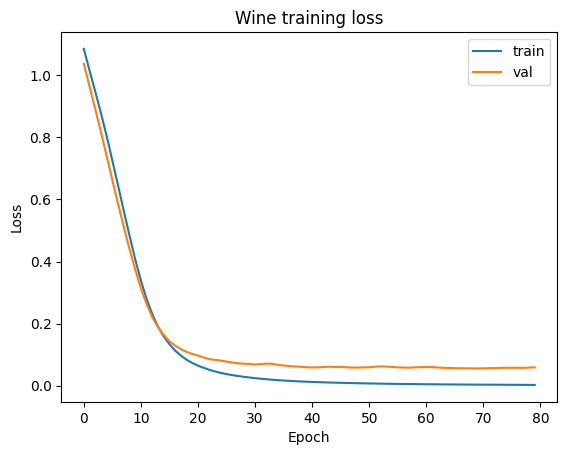

In [8]:
# If you don't have GPU change device to torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if __name__ == '__main__':
    device = torch.device('cuda')
    print('Using device:', device)
    model_wine, hist_wine = partB_wine(device)
    
    torch.cuda.empty_cache()   # frees up cached memory
    del model_wine # delete big models
    gc.collect()  